# Week 5  Introduction to Inferential Statistics and Hypothesis Testing with R
> by Lei Ding, Updated Mar. 2025

In [1]:
# 准备
#install.packages('ggplot2')
#install.packages('MASS')
library(ggplot2)

In [2]:
# 1. 显著性水平
pnorm(1.96, lower.tail=FALSE)
pnorm(2.2, lower.tail=FALSE)

[1] 0.0249979

[1] 0.01390345

## 1. 参数检验


	Shapiro-Wilk normality test

data:  x
W = 0.95286, p-value < 2.2e-16


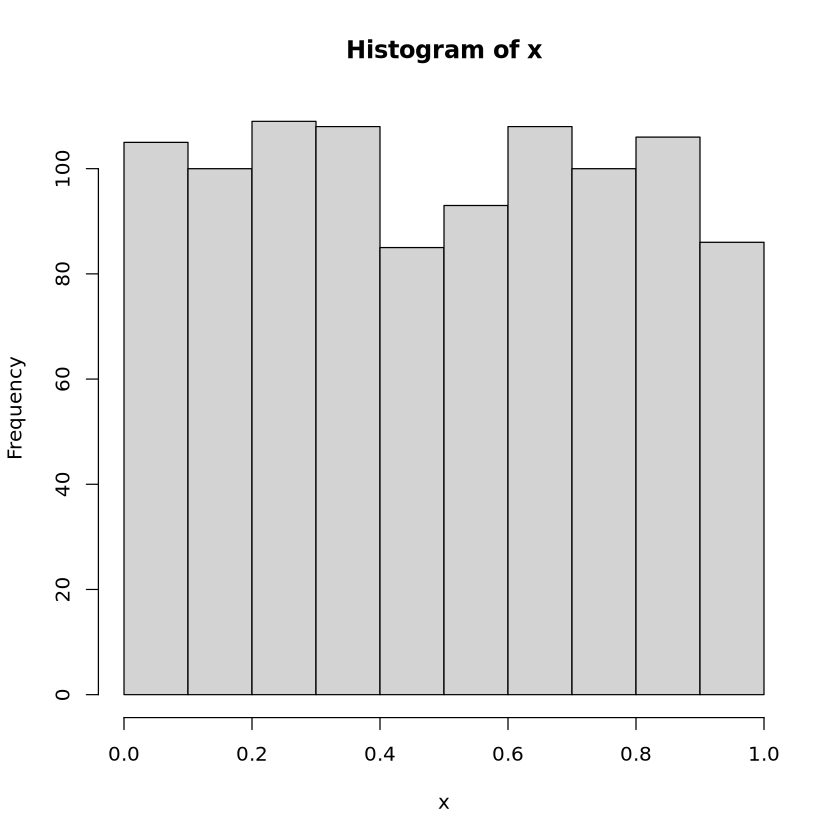

In [3]:
# 2. 随机样本的正态性检验
x = runif(1000)  # 均值分布样本
hist(x, main='Histogram of x')
shapiro.test(x)  # 夏皮罗检验

# p<0.05 拒绝正态性假设


	Shapiro-Wilk normality test

data:  y
W = 0.99759, p-value = 0.1497


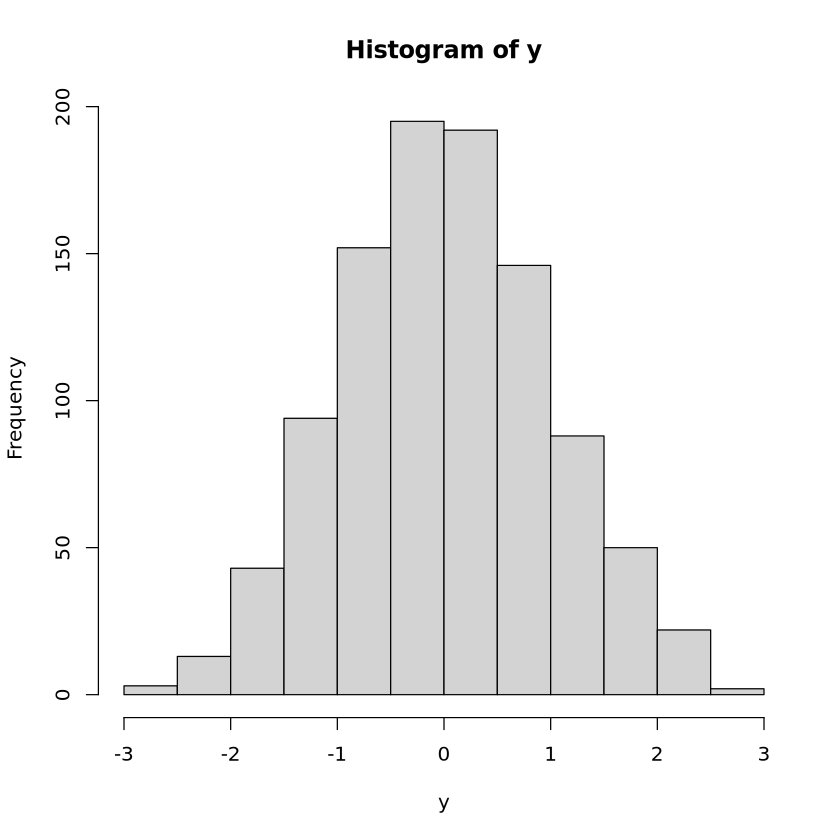

In [4]:
# 3. 随机样本的正态性检验
y = rnorm(1000)  # 正态分布样本
hist(y, main='Histogram of y')
shapiro.test(y)

# p>0.05 接受正态性假设

In [5]:
# 4. 美国女性平均体重为166.2磅的t检验
women
mean(women$weight)
sd(women$weight)
t.test(women$weight, mu=166.2)

# p<0.05，拒绝均值为166.2的假设

height,weight
<dbl>,<dbl>
58,115
59,117
60,120
61,123
62,126
63,129
64,132
65,135
66,139


[1] 136.7333

[1] 15.49869


	One Sample t-test

data:  women$weight
t = -7.3635, df = 14, p-value = 3.546e-06
alternative hypothesis: true mean is not equal to 166.2
95 percent confidence interval:
 128.1504 145.3162
sample estimates:
mean of x 
 136.7333 



	Paired t-test

data:  run$firstrun and run$secondrun
t = -22.786, df = 98, p-value < 2.2e-16
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -5.102290 -4.284741
sample estimates:
mean difference 
      -4.693515 


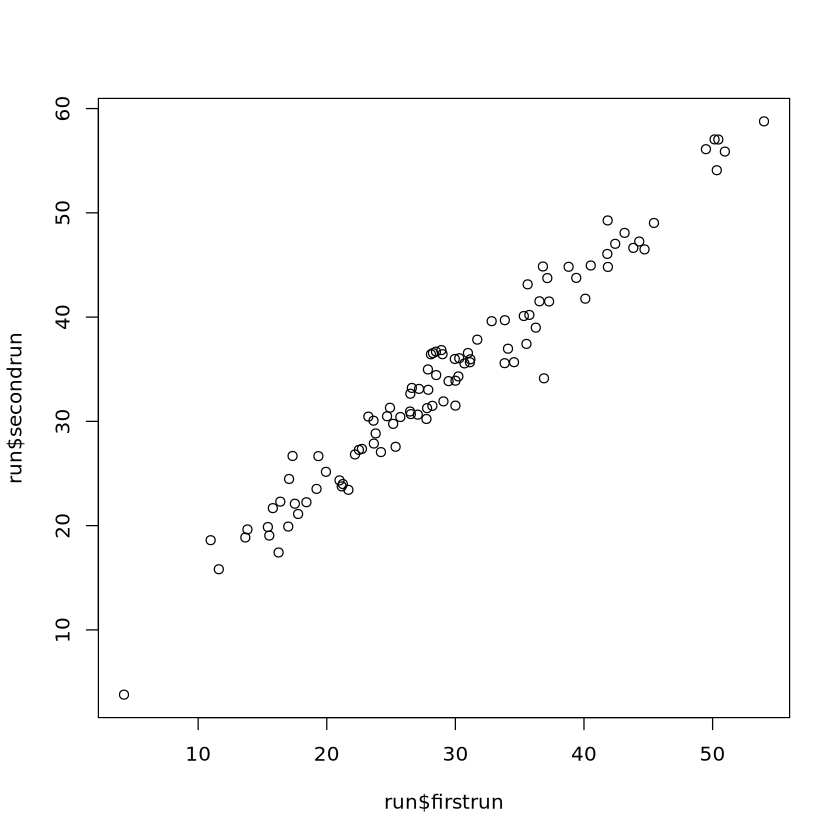

In [6]:
# 5. 成对样本的t检验
firstrun <- rnorm(99, 30, 10)
secondrun <- firstrun + rnorm(99, 5, 2)
finalrun <- secondrun + rnorm(99, 7, 3)
run <- data.frame(firstrun, secondrun, finalrun)
plot(run$firstrun, run$secondrun)
t.test(run$firstrun, run$secondrun, paired=TRUE)

# p<0.05，拒绝相同的假设，即firstrun与secondrun显著不同

group,weight
<chr>,<dbl>
Woman,38.9
Woman,61.2
Woman,73.3
Woman,21.8
Woman,63.4
Woman,64.6
Woman,48.4
Woman,48.8
Woman,48.5


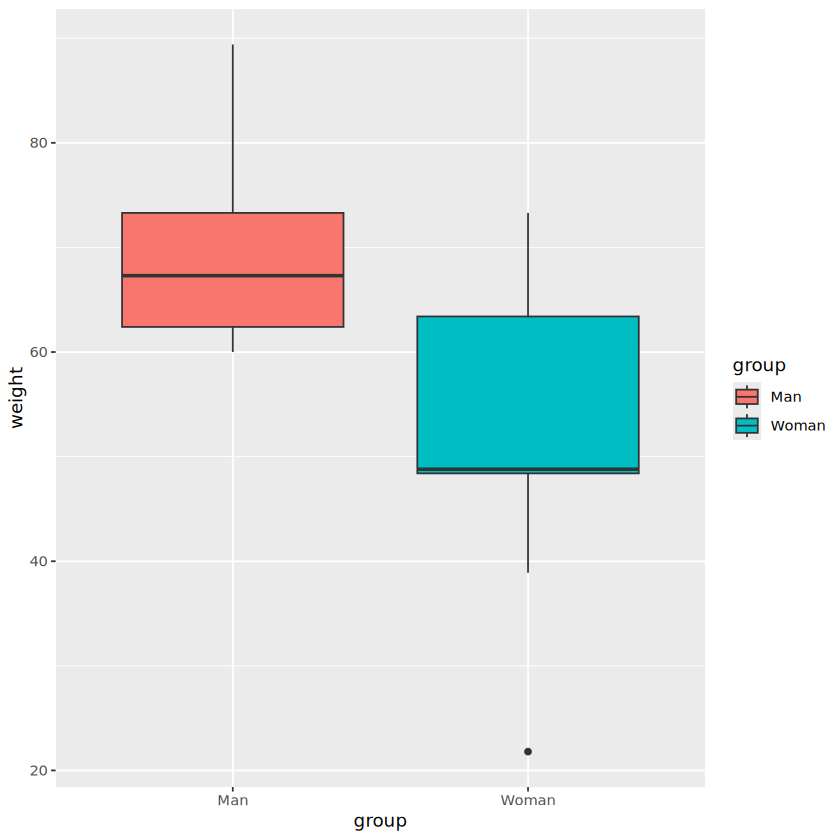

In [7]:
# 6. 女性与男性体重的t检验（非成对样本）
women_weight <- c(38.9, 61.2, 73.3, 21.8, 63.4, 64.6, 48.4, 48.8, 48.5)
men_weight <- c(67.8, 60, 63.4, 76, 89.4, 73.3, 67.3, 61.3, 62.4)
my_data <- data.frame(group=rep(c("Woman", "Man"), each=9), weight=c(women_weight, men_weight))
my_data
ggplot(my_data, aes(x=group, y=weight)) + geom_boxplot(aes(fill=group))

In [8]:
# 正态性检验
shapiro.test(women_weight)
shapiro.test(men_weight)

# p>0.05，女性与男性体重都服从正态分布


	Shapiro-Wilk normality test

data:  women_weight
W = 0.94266, p-value = 0.6101



	Shapiro-Wilk normality test

data:  men_weight
W = 0.86425, p-value = 0.1066


In [9]:
# 方差检验
var.test(women_weight, men_weight)

# p>0.05，女性与男性体重分布具有相同的方差


	F test to compare two variances

data:  women_weight and men_weight
F = 2.7675, num df = 8, denom df = 8, p-value = 0.1714
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
  0.6242536 12.2689506
sample estimates:
ratio of variances 
          2.767478 


In [10]:
# t检验
t.test(women_weight, men_weight, var.equal=TRUE)

# p<0.05，女性与男性体重显著不同


	Two Sample t-test

data:  women_weight and men_weight
t = -2.7842, df = 16, p-value = 0.01327
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -29.748019  -4.029759
sample estimates:
mean of x mean of y 
 52.10000  68.98889 


## 2. 非参数检验


	Wilcoxon rank sum test with continuity correction

data:  mpg by am
W = 42, p-value = 0.001871
alternative hypothesis: true location shift is not equal to 0


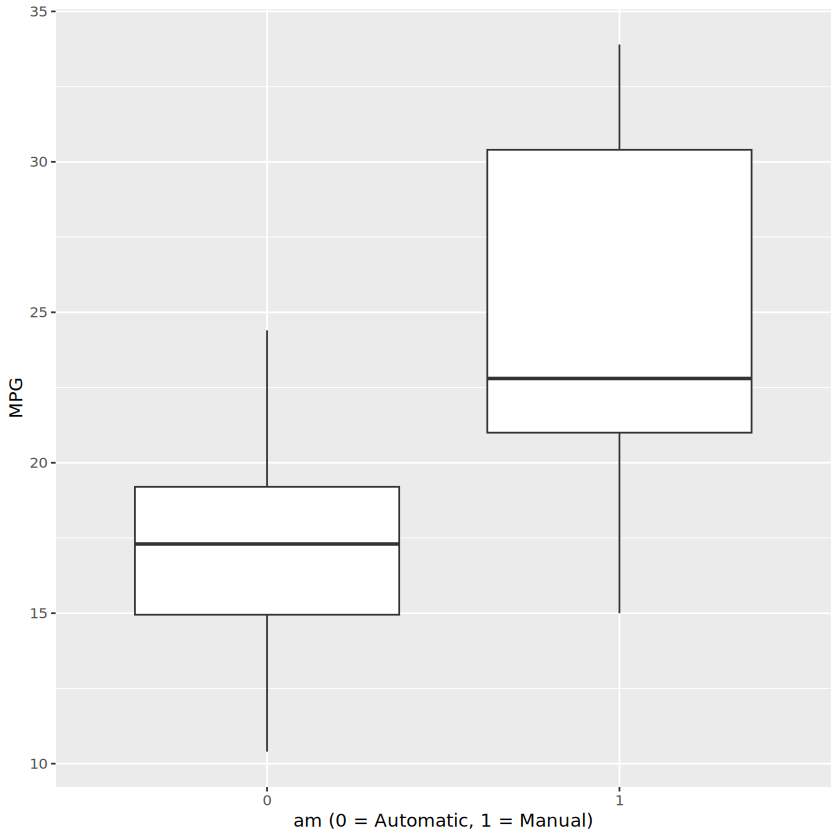

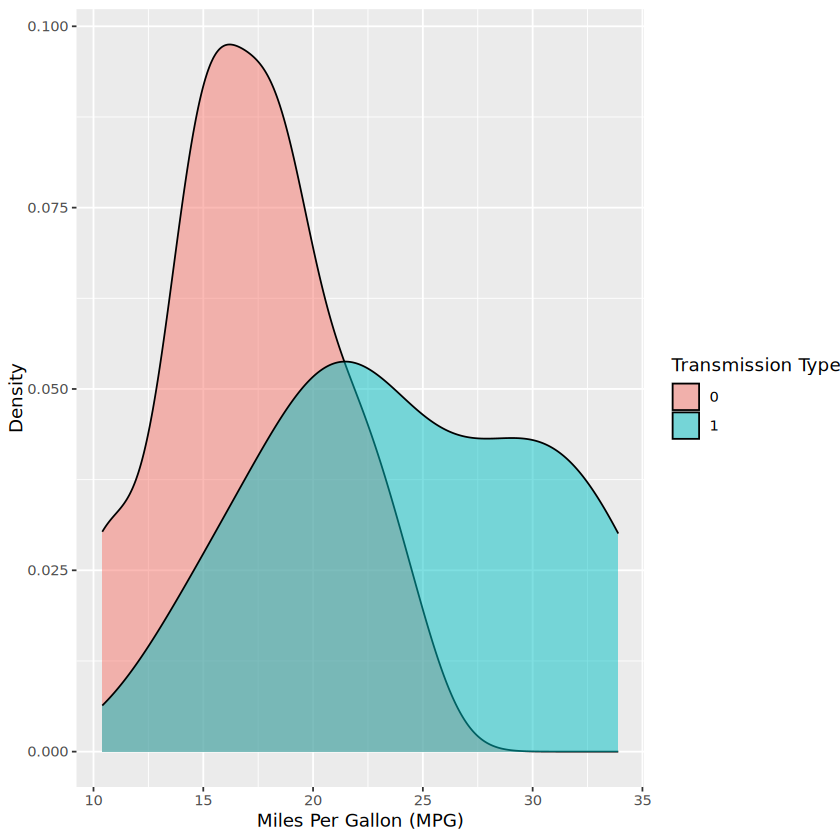

In [11]:
# 7. 手动挡与自动档油耗分布的U检验
wilcox.test(mpg ~ am, data=mtcars, exact=FALSE)
# 油耗显著不同

ggplot(mtcars, aes(x=factor(am), y=mpg)) +
  geom_boxplot() +
  labs(x="am (0 = Automatic, 1 = Manual)", y="MPG")

ggplot(mtcars, aes(x=mpg, fill=factor(am))) +
  geom_density(alpha=0.5) +
  labs(x="Miles Per Gallon (MPG)", y="Density", fill="Transmission Type")

In [12]:
# 8. 女性与男性体重的U检验
wilcox.test(women_weight, men_weight, paired=FALSE, exact=FALSE)

# 体重显著不同


	Wilcoxon rank sum test with continuity correction

data:  women_weight and men_weight
W = 15, p-value = 0.02712
alternative hypothesis: true location shift is not equal to 0



	Shapiro-Wilk normality test

data:  trees$Height
W = 0.96545, p-value = 0.4034



	Shapiro-Wilk normality test

data:  trees$Girth
W = 0.94117, p-value = 0.08893



	F test to compare two variances

data:  trees$Height and trees$Girth
F = 4.1227, num df = 30, denom df = 30, p-value = 0.0002127
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 1.987856 8.550249
sample estimates:
ratio of variances 
          4.122701 


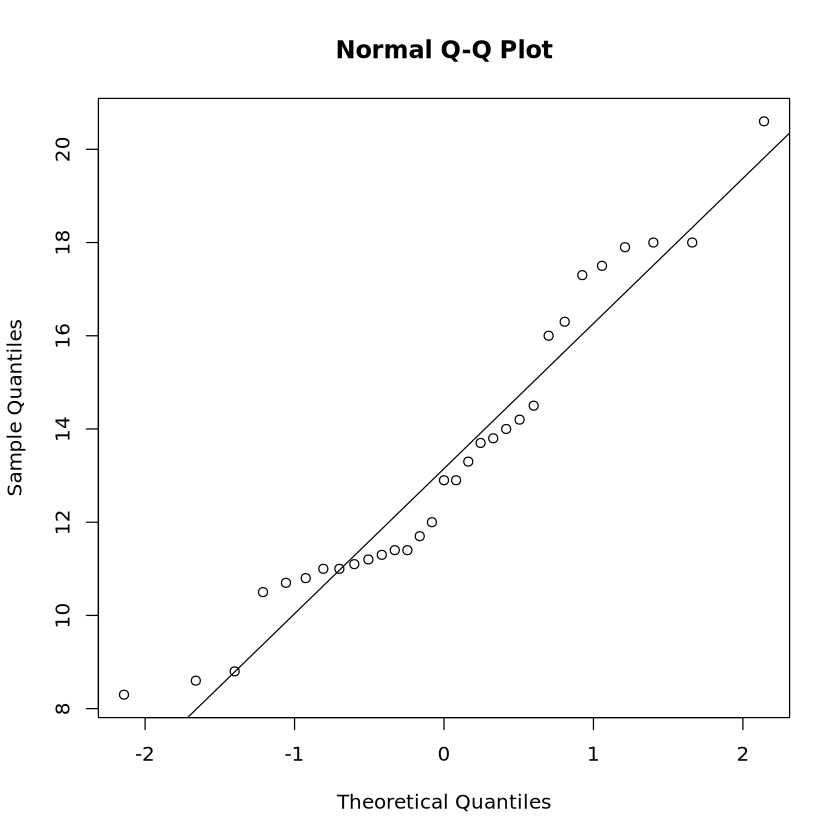

In [13]:
# 9. 黑樱桃树周长与树高方差的F检验
shapiro.test(trees$Height)
shapiro.test(trees$Girth)
# 接受正态分布

qqnorm(trees$Girth)
qqline(trees$Girth)

var.test(trees$Height, trees$Girth)
# 方差显著不同

In [14]:
# 10. 小学生近视比例的卡方检验
prop.test(320, 500, p=0.6)

# 比例为0.6


	1-sample proportions test with continuity correction

data:  320 out of 500, null probability 0.6
X-squared = 3.1688, df = 1, p-value = 0.07506
alternative hypothesis: true p is not equal to 0.6
95 percent confidence interval:
 0.5959891 0.6818256
sample estimates:
   p 
0.64 


In [15]:
# 11. 两组比例是否相等的卡方检验
prop.test(x=c(25, 5), n=c(30, 31))
# 两组比例显著不同

prop.test(x=c(25, 20), n=c(30, 31))
# 两组比例相同


	2-sample test for equality of proportions with continuity correction

data:  c(25, 5) out of c(30, 31)
X-squared = 24.927, df = 1, p-value = 5.955e-07
alternative hypothesis: two.sided
95 percent confidence interval:
 0.4533774 0.8907087
sample estimates:
   prop 1    prop 2 
0.8333333 0.1612903 



	2-sample test for equality of proportions with continuity correction

data:  c(25, 20) out of c(30, 31)
X-squared = 1.9022, df = 1, p-value = 0.1678
alternative hypothesis: two.sided
95 percent confidence interval:
 -0.05945583  0.43579991
sample estimates:
   prop 1    prop 2 
0.8333333 0.6451613 


In [16]:
# 12. 两组比例是否相等的卡方检验
prop.test(c(52, 72), c(100, 100))

# 两组比例显著不同


	2-sample test for equality of proportions with continuity correction

data:  c(52, 72) out of c(100, 100)
X-squared = 7.6613, df = 1, p-value = 0.005642
alternative hypothesis: two.sided
95 percent confidence interval:
 -0.34165357 -0.05834643
sample estimates:
prop 1 prop 2 
  0.52   0.72 


In [17]:
# 13. 大学生吸烟习惯与锻炼习惯的卡方独立性检验
library(MASS)
head(survey)
tbl = table(survey$Smoke, survey$Exer)
tbl
chisq.test(tbl)

# 吸烟与锻炼没有显著的统计关系（独立）

,Sex,Wr.Hnd,NW.Hnd,W.Hnd,Fold,Pulse,Clap,Exer,Smoke,Height,M.I,Age
,<fct>,<dbl>,<dbl>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<dbl>,<fct>,<dbl>
1,Female,18.5,18.0,Right,R on L,92,Left,Some,Never,173.00,Metric,18.250
2,Male,19.5,20.5,Left,R on L,104,Left,None,Regul,177.80,Imperial,17.583
3,Male,18.0,13.3,Right,L on R,87,Neither,None,Occas,NA,NA,16.917
4,Male,18.8,18.9,Right,R on L,NA,Neither,None,Never,160.00,Metric,20.333
5,Male,20.0,20.0,Right,Neither,35,Right,Some,Never,165.00,Metric,23.667
6,Female,18.0,17.7,Right,L on R,64,Right,Some,Never,172.72,Imperial,21.000


       
        Freq None Some
  Heavy    7    1    3
  Never   87   18   84
  Occas   12    3    4
  Regul    9    1    7

Warning message in chisq.test(tbl):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  tbl
X-squared = 5.4885, df = 6, p-value = 0.4828
